<a href="https://colab.research.google.com/github/YBcho02/gasoline-price-search-index/blob/main/notebook/VAR_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAR and its IRF on GPS index




| | Spec A | Spec B |
|---|---|---|
| Identified shock | **OPU** (oil price uncertainty) | **Real gasoline price** |
| Ordering | OPU → S&P → shadow → employment → IP → GPS | gas price → S&P → shadow → employment → IP → GPS |





---
## 1. Setting

Note : The Wu–Xia shadow rate, from
<https://www.atlantafed.org/cqer/research/wu-xia-shadow-federal-funds-rate>

In [2]:
#!pip install numpy pandas matplotlib scipy statsmodels openpyxl
#!pip install yfinance   # for the S&P 500
#import json
import pandas as pd
#import requests
#from requests.adapters import HTTPAdapter
#from requests.packages.urllib3.util.retry import Retry
#from requests import status_codes
#from pytrends import exceptions
from urllib.parse import quote
import datetime
from datetime import datetime, date, time
import time
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
from pathlib import Path
import statsmodels.api as sm
import os, warnings

In [27]:
# Clone Git Repo
REPO = "gasoline-price-search-index"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path("/content") / REPO
    if ROOT.exists():
        !git -C {ROOT} pull -q
    else:
        !git clone -q https://github.com/YBcho02/{REPO}.git {ROOT}
else:
    ROOT = Path.cwd().parent



error: The following untracked working tree files would be overwritten by merge:
	output/fig3_baseline_irf.png
	output/fig4_direct_effects.png
	output/fig5_alt_shocks.png
	output/fig_inputs.png
	output/table3_fevd.csv
	output/table4_correlations.csv
	output/table_peak.csv
Please move or remove them before you merge.
Aborting


In [4]:

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------- the indices
OPU_CSV   = "OPU_index_monthly.csv"    # oil price uncertainty
RESP_CSV  = "gps_index.csv"         # gasoline price search -- the response
RESP_NAME = "GPS index"

OPU_LOG   = True     # OPU is heavily right-skewed; 100*log(.)
RESP_LOG  = True     # full-sample GPS skew is 2.27

DATA_DIR = Path("/content") / REPO / "data"
OUT_DIR  = Path("/content") / REPO / "output"

# ----------------------------------------------------------------- sample
SAMPLE_START = "2010-01"
SAMPLE_END   = "2026-08"    # each spec trims to what its own data supports
SPLIT_DATE   = "2020-01"    # for the pre/post stability check

# ----------------------------------------------------------------- specification
MACRO_BLOCK = ["S&P 500", "Shadow rate", "Employment", "Ind. production"]

SEASONAL = "none"        # "dummies" | "adjust" | "none" # already seasonally adjusted when we computed GPS index
NLAGS    = 3
HORIZON  = 30
NBOOT    = 2000
CI       = 90
SEED     = 20260828

MACRO_SOURCE = "auto"       # "auto" | "real"

# ----------------------------------------------------------------- plotting setups
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})
BLUE, RED, GREY, BAND, ORANGE, GREEN = (
    "#1f4e9c", "#c8102e", "#8a8a8a", "#bcd6f0", "#e08214", "#2e7d32")

print(f"Sample: {SAMPLE_START} to {SAMPLE_END}   lags={NLAGS}   bootstraps={NBOOT}")
print(f"Response: {RESP_NAME} ({'logs' if RESP_LOG else 'levels'}), ordered last in both specs")

Sample: 2010-01 to 2026-08   lags=3   bootstraps=2000
Response: GPS index (logs), ordered last in both specs


---
## 2. Loading the indices


In [25]:
def load_index(path, name):
    candidates = [DATA_DIR / "processed" / path, DATA_DIR / "raw" / path]
    src = next((p for p in candidates if p.exists()), None)
    if src is None:
        raise FileNotFoundError(f"Could not find {path}. Looked in: "
                                + ", ".join(str(c) for c in candidates))
    df = pd.read_csv(src)
    date_col = df.columns[0]
    val_col = next((c for c in df.columns[1:]
                    if pd.to_numeric(df[c], errors="coerce").notna().any()), df.columns[1])
    dt = pd.to_datetime(df[date_col], format="%m/%d/%Y", errors="coerce")
    if dt.isna().all():
        dt = pd.to_datetime(df[date_col])
    s = pd.Series(pd.to_numeric(df[val_col], errors="coerce").values,
                  index=pd.PeriodIndex(dt, freq="M"), name=name).dropna()

    if s.index.duplicated().any():
        n = int(s.index.duplicated().sum()); s = s.groupby(level=0).mean()
        print(f"  note: averaged {n} duplicated month(s)")
    full = pd.period_range(s.index[0], s.index[-1], freq="M")
    if len(full.difference(s.index)):
        miss = full.difference(s.index)
        print(f"  WARNING: {len(miss)} missing month(s) -- interpolated")
        s = s.reindex(full).interpolate()
    print(f"  {name:10s} <- {src.name}: {s.index[0]} to {s.index[-1]}, n={len(s)}")
    return s


def trim_to_after_last_zero(s):
    z = s[s == 0]
    if len(z):
        start = z.index[-1] + 1
        print(f"  {s.name}: {len(z)} zero month(s), last at {z.index[-1]} -> start {start}")
        s = s.loc[start:]
    return s


def transform(s, use_log, name):
    out = 100*np.log(s) if use_log else s.copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out.name = name
    return out


opu_level  = trim_to_after_last_zero(load_index(OPU_CSV, "OPU"))
resp_level = load_index(RESP_CSV, RESP_NAME)

print("\nDistribution check over the estimation window (skew near zero is what we want):")
win = lambda s: s.loc[pd.Period(SAMPLE_START, "M"):pd.Period(SAMPLE_END, "M")]
for lab, s, use_log in [("OPU", opu_level, OPU_LOG), (RESP_NAME, resp_level, RESP_LOG)]:
    w = win(s)
    print(f"  {lab:10s} levels skew={w.skew():6.2f}   log skew={np.log(w).skew():6.2f}"
          f"   -> using {'LOGS' if use_log else 'LEVELS'}")

opu_s  = transform(opu_level,  OPU_LOG,  "OPU")
resp_s = transform(resp_level, RESP_LOG, RESP_NAME)

  OPU        <- OPU_index_monthly.csv: 1969-01 to 2026-03, n=687
  OPU: 108 zero month(s), last at 1982-09 -> start 1982-10
  GPS index  <- gps_index.csv: 2010-01 to 2026-08, n=200

Distribution check over the estimation window (skew near zero is what we want):
  OPU        levels skew=  4.14   log skew= -0.06   -> using LOGS
  GPS index  levels skew=  2.32   log skew=  1.34   -> using LOGS


---
## 3. Macroeconomic data

Four macro series for the block, plus the gasoline price and CPI which supply Spec B's shock.

In [7]:
def fetch_fred(series_id, how="mean"):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    s = pd.to_numeric(df.set_index(date_col).iloc[:, 0], errors="coerce").dropna()
    s.index = pd.PeriodIndex(s.index, freq="M")
    s = s.groupby(level=0).last() if how == "last" else s.groupby(level=0).mean()
    return s.rename(series_id)


def fetch_fred_first_available(candidates, how="mean"):
    for sid in candidates:
        try:
            s = fetch_fred(sid, how=how)
            if len(s) > 24:
                print(f"  {sid}: {s.index[0]} to {s.index[-1]}")
                return s.rename(sid)
        except Exception as e:
            print(f"  {sid} unavailable ({type(e).__name__})")
    raise RuntimeError(f"none of {candidates} could be downloaded")


def fetch_sp500():
    try:
        import yfinance as yf
        px = yf.download("^GSPC", start="2005-01-01", progress=False, auto_adjust=False)
        col = "Close" if "Close" in px.columns else px.columns[0]
        s = px[col].squeeze()
        s.index = pd.PeriodIndex(pd.to_datetime(s.index), freq="M")
        return s.groupby(level=0).last().rename("SP500")
    except Exception as e:
        print(f"  yfinance unavailable ({type(e).__name__}); using FRED SP500")
        return fetch_fred("SP500", how="last").rename("SP500")


SHADOW_FILES = "WuXiaShadowRate.xlsx"


def _read_shadow_file(path):
    """Read a Wu-Xia file into a monthly Series, tolerating the formats it ships in.

    Handles .xlsx or .csv, with or without a header row, and dates written as YYYYMM
    (200401), ISO (2004-01), or anything pandas can parse. Picks the rate column by
    name when there is one, otherwise the last numeric column.
    """

    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xls"):
        raw = pd.read_excel(path, sheet_name=0)
    else:
        raw = pd.read_csv(path)
        first = str(raw.columns[0])          # headerless file: row 1 became the header
        if first.replace("-", "").replace("/", "").replace(".", "").isdigit():
            raw = pd.read_csv(path, header=None)
    raw = raw.dropna(how="all")
    if raw.shape[1] < 2:
        raise ValueError(f"{path.name}: expected >=2 columns, got {raw.shape[1]}")

    named = [c for c in raw.columns
             if any(k in str(c).lower() for k in ("shadow", "rate", "wu", "value"))]
    vcol = named[-1] if named else raw.columns[-1]
    dcol = raw.columns[0]

    dt = pd.to_datetime(raw[dcol].astype(str).str.strip(), format="%Y%m", errors="coerce")
    if dt.isna().all():
        dt = pd.to_datetime(raw[dcol], errors="coerce")
    v = pd.to_numeric(raw[vcol], errors="coerce")
    ok = dt.notna() & v.notna()
    if not ok.any():
        raise ValueError(f"{path.name}: could not parse any (date, value) pairs")
    s = pd.Series(v[ok].values, index=pd.PeriodIndex(dt[ok], freq="M"), name="shadow")
    return s.groupby(level=0).mean().sort_index()


def splice_shadow_rate(wuxia, fedfunds, tol=0.20, verbose=True):
    """Take Wu-Xia where it exists, fall back to the effective fed funds rate elsewhere.

    The Wu-Xia shadow rate is only informative while the zero lower bound binds; away
    from the ZLB it coincides with the policy rate by construction, which is why the
    published file typically covers only the constrained months. Filling the blanks with
    FEDFUNDS is therefore splicing two measurements of the same object rather than
    approximating one with the other -- but the diagnostics below test that claim
    instead of assuming it.

    Fills by ACTUAL MISSING MONTH rather than by a hardcoded cutoff date, so interior
    gaps are handled as well as a stale tail. Returns (series, report).
    """
    wuxia, fedfunds = wuxia.dropna().sort_index(), fedfunds.dropna().sort_index()
    if len(wuxia) == 0:
        raise ValueError("Wu-Xia series is empty after dropping NaNs")

    idx = pd.period_range(min(wuxia.index[0], fedfunds.index[0]),
                          max(wuxia.index[-1], fedfunds.index[-1]), freq="M")
    wx, ff = wuxia.reindex(idx), fedfunds.reindex(idx)

    out = wx.copy()
    filled = out.isna() & ff.notna()
    out[filled] = ff[filled]
    source = pd.Series(np.where(wx.notna(), "Wu-Xia",
                                np.where(filled, "FEDFUNDS", "missing")), index=idx)

    both = wx.notna() & ff.notna()
    n_ov = int(both.sum())
    gap = (wx[both] - ff[both]).abs()
    zlb = (wx.notna() & (wx < ff - tol)) if n_ov else wx.notna()

    seams, src = [], source.values
    for i in range(1, len(idx)):
        if src[i] != src[i - 1] and "missing" not in (src[i], src[i - 1]):
            seams.append({"month": str(idx[i]), "from": src[i - 1], "to": src[i],
                          "jump_pp": round(abs(out.iloc[i] - out.iloc[i - 1]), 3)})
    seams = pd.DataFrame(seams)

    if verbose:
        print(f"  Wu-Xia months       : {int(wx.notna().sum())} "
              f"({wuxia.index[0]} to {wuxia.index[-1]})")
        print(f"  filled from FEDFUNDS: {int(filled.sum())}")
        print(f"  still missing       : {int(out.isna().sum())}")
        if n_ov:
            print(f"  overlap             : {n_ov} months, "
                  f"max |Wu-Xia - FEDFUNDS| = {gap.max():.2f} pp")
        else:
            print("  overlap             : none -- the two cannot be cross-checked")
        print(f"  ZLB-binding months  : {int(zlb.sum())} "
              f"(Wu-Xia more than {tol} pp below fed funds)")
        if len(seams):
            big = seams[seams.jump_pp > 0.5]
            print(f"  source switches     : {len(seams)}", end="")
            print(f", {len(big)} with a jump > 0.5 pp -- inspect" if len(big)
                  else ", none with a jump > 0.5 pp")
        if out.isna().any():
            print("  WARNING: gaps remain; build_dataset will drop those months")

    return out.rename("shadow"), pd.DataFrame(
        {"shadow": out, "wuxia": wx, "fedfunds": ff, "source": source, "zlb": zlb})


def load_shadow_rate(return_report=False):
    """Wu-Xia shadow rate spliced with FEDFUNDS; FEDFUNDS alone if no file is present."""
    path = DATA_DIR / "raw" /SHADOW_FILES if (DATA_DIR / "raw" /SHADOW_FILES).exists() else None
    ffr = fetch_fred("FEDFUNDS")
    if path is None:
        print(f"  WARNING: none of {SHADOW_FILES} found in {DATA_DIR}/ -> FEDFUNDS only.")
        print("           The ZLB years will carry no policy-stance information.")
        return (ffr.rename("shadow"), None) if return_report else ffr.rename("shadow")

    print(f"  Wu-Xia shadow rate <- {path.name}")
    s, report = splice_shadow_rate(_read_shadow_file(path), ffr)
    return (s, report) if return_report else s


def load_macro_real():
    print("Downloading macro data ...")
    d = {"sp500": fetch_sp500(), "shadow": load_shadow_rate(),
         "emp": fetch_fred("PAYEMS"), "ip": fetch_fred("INDPRO"),
         "cpi": fetch_fred("CPIAUCSL")}
    for key, ids in [("gas_nom", ["GASREGCOVM", "GASREGM", "APU000074714"]),
                     ("oil_wti", ["MCOILWTICO", "WTISPLC"]),
                     ("oil_brent", ["POILBREUSDM"]),
                     ("unrate", ["UNRATE"]), ("vix", ["VIXCLS"]),
                     ("epu", ["USEPUINDXM"])]:
        try:
            d[key] = fetch_fred_first_available(ids)
        except Exception:
            print(f"  {key} unavailable, skipping")
    return d







macro = load_macro_real()

print("\nSeries:", ", ".join(macro.keys()))

  Wu-Xia shadow rate <- WuXiaShadowRate.xlsx
  Wu-Xia months       : 386 (1990-01 to 2022-02)
  filled from FEDFUNDS: 480
  still missing       : 0
  overlap             : 386 months, max |Wu-Xia - FEDFUNDS| = 3.08 pp
  ZLB-binding months  : 180 (Wu-Xia more than 0.2 pp below fed funds)
  source switches     : 2, none with a jump > 0.5 pp
  GASREGCOVM: 1990-09 to 2026-08
  MCOILWTICO: 1986-01 to 2026-08
  POILBREUSDM: 1992-01 to 2026-07
  UNRATE: 1948-01 to 2026-08
  VIXCLS: 1990-01 to 2026-09
  USEPUINDXM: 1985-01 to 2026-08

Series: sp500, shadow, emp, ip, cpi, gas_nom, oil_wti, oil_brent, unrate, vix, epu


  Wu-Xia shadow rate <- WuXiaShadowRate.xlsx
  Wu-Xia months       : 386 (1990-01 to 2022-02)
  filled from FEDFUNDS: 480
  still missing       : 0
  overlap             : 386 months, max |Wu-Xia - FEDFUNDS| = 3.08 pp
  ZLB-binding months  : 180 (Wu-Xia more than 0.2 pp below fed funds)
  source switches     : 2, none with a jump > 0.5 pp

Source composition over the estimation window:
source
Wu-Xia      146
FEDFUNDS     54


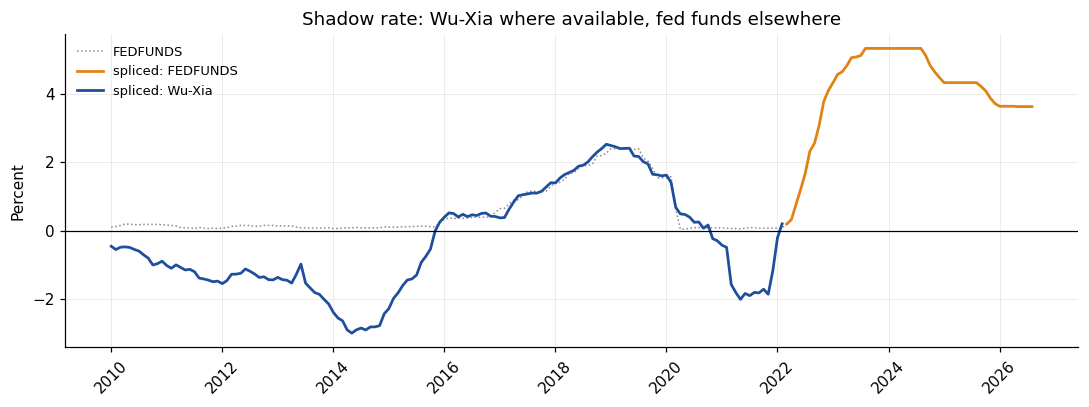

In [8]:

shadow, shadow_report = load_shadow_rate(return_report=True)
macro["shadow"] = shadow          # keep the macro block in sync


if shadow_report is not None:
    rep = shadow_report.loc[pd.Period(SAMPLE_START, "M"):pd.Period(SAMPLE_END, "M")]
    print("\nSource composition over the estimation window:")
    print(rep["source"].value_counts().to_string())

    fig, ax = plt.subplots(figsize=(10, 3.8))
    x = [p.ordinal for p in rep.index]
    ax.plot(x, rep["fedfunds"].values, color=GREY, lw=1.0, ls=":", label="FEDFUNDS")
    for src, c in [("FEDFUNDS", ORANGE), ("Wu-Xia", BLUE)]:
        m = (rep["source"] == src).values
        ax.plot(x, np.where(m, rep["shadow"].values, np.nan),
                color=c, lw=1.8, label=f"spliced: {src}")
    ax.axhline(0, color="k", lw=.8)
    ticks = [p.ordinal for p in rep.index if p.month == 1 and p.year % 2 == 0]
    ax.set_xticks(ticks)
    ax.set_xticklabels([pd.Period(ordinal=t, freq="M").year for t in ticks], rotation=45)
    ax.set_ylabel("Percent"); ax.legend(fontsize=8.5)
    ax.set_title("Shadow rate: Wu-Xia where available, fed funds elsewhere")
    plt.tight_layout(); plt.savefig(OUT_DIR / "fig_shadow_splice.png"); plt.show()

---
## 4. The two specifications

Each spec is a dictionary holding a shock name, the shock series, and a Cholesky ordering. Every
function below takes a spec.


In [11]:
L100 = lambda x: 100*np.log(x)

#real_gas = macro['oil_brent']
real_gas = macro["gas_nom"] / macro["cpi"] * 100
gas_s = L100(real_gas).rename("Real gas price")

SPECS = {
    "OPU shock":       dict(shock="OPU",            series=opu_s, color=BLUE),
    "Gas price shock": dict(shock="Real gas price", series=gas_s, color=RED),
}
for sp in SPECS.values():
    sp["order"] = [sp["shock"]] + MACRO_BLOCK + [RESP_NAME]

UNITS = {"OPU": "Percent" if OPU_LOG else "Index points",
         "Real gas price": "Percent", "S&P 500": "Percent",
         "Shadow rate": "Percentage points", "Employment": "Percent",
         "Ind. production": "Percent",
         RESP_NAME: "Percent" if RESP_LOG else "Index points"}


def build_dataset(spec, start=SAMPLE_START, end=SAMPLE_END, order=None,
                  seasonal=None, extra=None, resp=None):

    order = spec["order"] if order is None else order
    sh = spec["series"]
    rs = resp_s if resp is None else resp


    cols = {spec["shock"]: sh,
            "S&P 500":         L100(macro["sp500"]),
            "Shadow rate":     macro["shadow"],
            "Employment":      L100(macro["emp"]),
            "Ind. production": L100(macro["ip"]),
            RESP_NAME:         rs}
    if extra:
        cols.update(extra)
    df = pd.DataFrame({k: cols[k] for k in order})
    return df.loc[pd.Period(start, "M"):pd.Period(end, "M")].dropna()


def month_dummies(index):
    """11 monthly dummies; January is the omitted base."""
    mo = np.array([p.month for p in index])
    return np.column_stack([(mo == m).astype(float) for m in range(2, 13)])


def det_terms(df, seasonal=None):
    seasonal = SEASONAL if seasonal is None else seasonal
    return month_dummies(df.index) if seasonal == "dummies" else None


def pos(df, name):
    return list(df.columns).index(name)


rows = []
for lab, sp in SPECS.items():
    d = build_dataset(sp)
    sp["data"] = d
    K = d.shape[1]; nd = 1 + (11 if SEASONAL == "dummies" else 0)
    npar = K*NLAGS + nd
    rows.append({"Spec": lab, "Shock": sp["shock"],
                 "Start": str(d.index[0]), "End": str(d.index[-1]), "T": len(d),
                 "Params/eq": npar, "Obs/param": round((len(d)-NLAGS)/npar, 1)})
display(pd.DataFrame(rows).set_index("Spec"))

,Shock,Start,End,T,Params/eq,Obs/param
Spec,,,,,,
OPU shock,OPU,2010-01,2026-03,195,19,10.1
Gas price shock,Real gas price,2010-01,2026-07,198,19,10.3


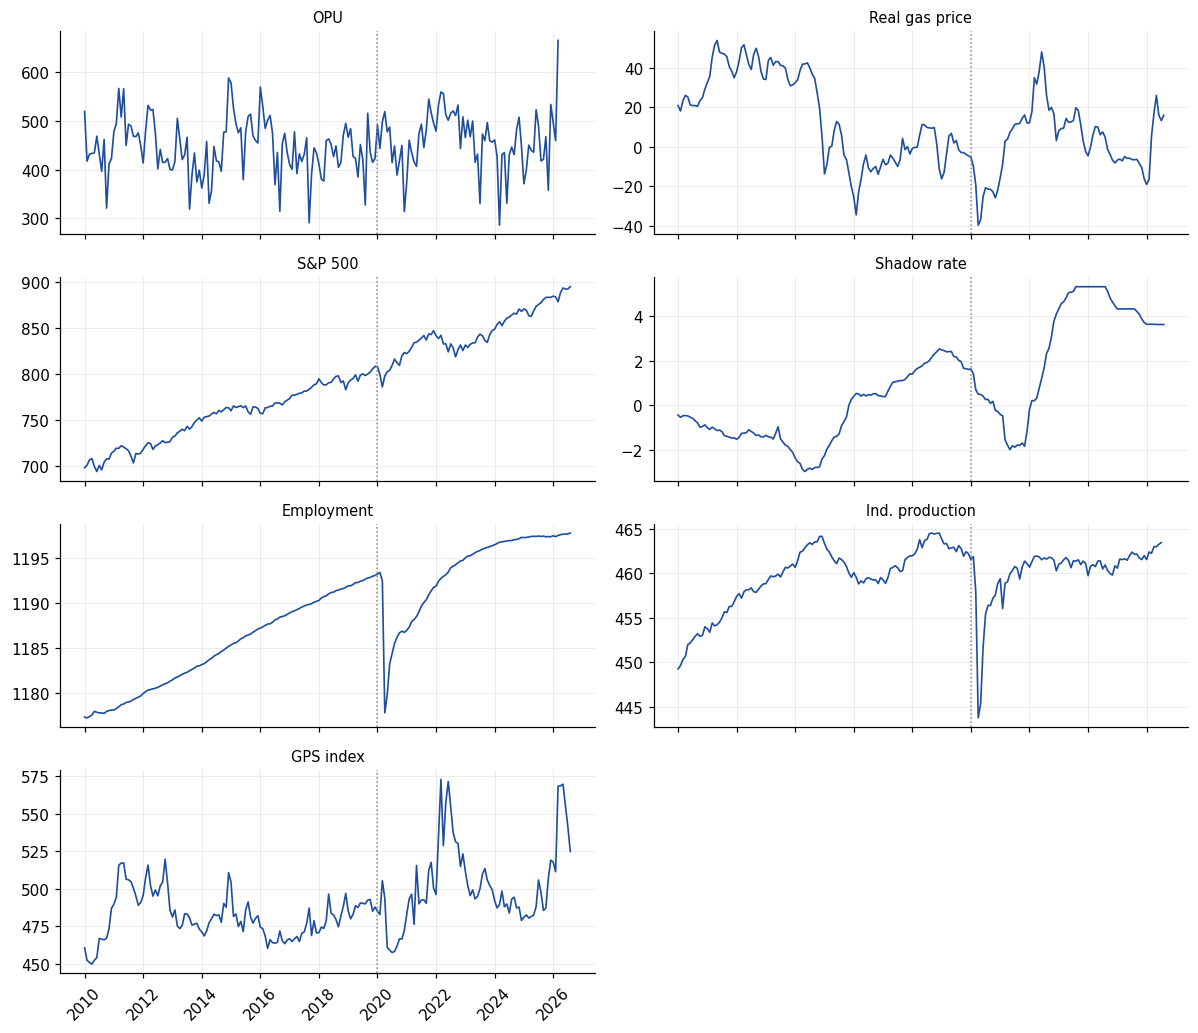

In [12]:
# ---- plot the inputs -----------------------------------------------------------
allvars = ["OPU", "Real gas price"] + MACRO_BLOCK + [RESP_NAME]
series_map = {"OPU": opu_s, "Real gas price": gas_s, RESP_NAME: resp_s,
              "S&P 500": L100(macro["sp500"]), "Shadow rate": macro["shadow"],
              "Employment": L100(macro["emp"]), "Ind. production": L100(macro["ip"])}

fig, axes = plt.subplots(4, 2, figsize=(11, 9.5), sharex=True)
for ax, col in zip(axes.ravel(), allvars):
    s = win(series_map[col]).dropna()
    ax.plot([p.ordinal for p in s.index], s.values, color=BLUE, lw=1.1)
    ax.set_title(col, fontsize=9.5)
    ax.axvline(pd.Period(SPLIT_DATE, "M").ordinal, color=GREY, lw=1, ls=":")
for ax in axes.ravel()[len(allvars):]:
    ax.set_visible(False)
ref = win(resp_s)
ticks = [p.ordinal for p in ref.index if p.month == 1 and p.year % 2 == 0]
for ax in axes.ravel():
    if ax.get_visible():
        ax.set_xticks(ticks)
        ax.set_xticklabels([pd.Period(ordinal=t, freq="M").year for t in ticks], rotation=45)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_inputs.png"); plt.show()

### 4.1 Unit-root diagnostics

In [13]:
from statsmodels.tsa.stattools import adfuller

rows = []
for name in allvars:
    s = win(series_map[name]).dropna()
    stat, p, lags, nobs, crit, _ = adfuller(s.values, autolag="AIC", regression="c")
    rows.append({"Variable": name, "ADF stat": round(stat, 3), "p-value": round(p, 3),
                 "5% crit": round(crit["5%"], 3), "Lags": lags})
print("Augmented Dickey-Fuller (constant, AIC lag selection).")
print("H0: unit root. Reject when the statistic is below the 5% critical value.\n")
pd.DataFrame(rows).set_index("Variable")

Augmented Dickey-Fuller (constant, AIC lag selection).
H0: unit root. Reject when the statistic is below the 5% critical value.



,ADF stat,p-value,5% crit,Lags
Variable,,,,
OPU,-4.556,0.000,-2.877,2
Real gas price,-2.399,0.142,-2.876,2
S&P 500,0.251,0.975,-2.876,2
Shadow rate,-2.152,0.224,-2.877,6
Employment,-1.293,0.633,-2.876,2
Ind. production,-3.369,0.012,-2.876,2
GPS index,-3.435,0.010,-2.876,0


---
## 5. The VAR toolkit

$$A\,y_t = c + \sum_{k=1}^{3} B_k\, y_{t-k} + u_t$$

estimated in reduced form with $A$ unit lower triangular(Cholesky). Written by hand rather than
via `statsmodels.tsa.VAR` because we need individual structural coefficients zeroed and the
system re-solved, which no library exposes.


In [14]:
def build_lagmat(Y, p, det=None):
    T = Y.shape[0]
    X = [np.ones((T - p, 1))]
    if det is not None:
        X.append(det[p:])
    X += [Y[p - lag: T - lag] for lag in range(1, p + 1)]
    return np.hstack(X), Y[p:]


def fit_var(Y, p, det=None):
    X, Yt = build_lagmat(Y, p, det)
    B, *_ = np.linalg.lstsq(X, Yt, rcond=None)
    U = Yt - X @ B
    Sigma = U.T @ U / (Yt.shape[0] - X.shape[1])
    n = Y.shape[1]
    ndet = 1 + (0 if det is None else det.shape[1])
    A = [B[ndet + n*(i - 1): ndet + n*i, :].T for i in range(1, p + 1)]
    D = X[:, :ndet] @ B[:ndet]
    return dict(B=B, A=A, U=U, Sigma=Sigma, D=D, p=p, n=n, T=Yt.shape[0])


def ma_reps(A, H):
    n, p = A[0].shape[0], len(A)
    Psi = [np.eye(n)]
    for h in range(1, H + 1):
        S = np.zeros((n, n))
        for i in range(1, min(h, p) + 1):
            S += A[i - 1] @ Psi[h - i]
        Psi.append(S)
    return Psi


def irf_chol(A, Sigma, H, shock=0, P=None):
    P = np.linalg.cholesky(Sigma) if P is None else P
    return np.array([Psi @ P for Psi in ma_reps(A, H)])[:, :, shock]


def fevd(A, Sigma, horizons):
    P = np.linalg.cholesky(Sigma)
    Th = np.array([Psi @ P for Psi in ma_reps(A, max(horizons))])
    out = {}
    for H in horizons:
        contrib = (Th[:H] ** 2).sum(axis=0)
        out[H] = contrib / contrib.sum(axis=1, keepdims=True)
    return out


def simulate_var(D, A, U, Y0):
    p, n, T = len(A), A[0].shape[0], U.shape[0]
    Y = np.zeros((T + p, n)); Y[:p] = Y0
    for t in range(p, T + p):
        y = D[t - p].copy()
        for i in range(1, p + 1):
            y = y + A[i - 1] @ Y[t - i]
        Y[t] = y + U[t - p]
    return Y


def irf_with_bands(Y, p, H, shock=0, det=None, nboot=NBOOT, ci=CI, seed=SEED,
                   transform=None):
    rng = np.random.default_rng(seed)
    m = fit_var(Y, p, det)
    point = transform(m, H, shock) if transform else irf_chol(m["A"], m["Sigma"], H, shock)
    U = m["U"] - m["U"].mean(axis=0); Tb = U.shape[0]
    draws, failed = [], 0
    for _ in range(nboot):
        Yb = simulate_var(m["D"], m["A"], U[rng.integers(0, Tb, Tb)], Y[:p])
        try:
            mb = fit_var(Yb, p, det)
            draws.append(transform(mb, H, shock) if transform
                         else irf_chol(mb["A"], mb["Sigma"], H, shock))
        except np.linalg.LinAlgError:
            failed += 1
    if failed:
        print(f"  ({failed} bootstrap draws discarded: non-PSD covariance)")
    draws = np.array(draws)
    a = (100 - ci)/2
    lo, hi = np.percentile(draws, [a, 100 - a], axis=0)
    return point, lo, hi, m


def to_structural(A, Sigma):
    P = np.linalg.cholesky(Sigma)
    D = np.diag(np.diag(P))
    L = P @ np.linalg.inv(D)
    return np.linalg.inv(L), D, [np.linalg.inv(L) @ Ai for Ai in A]


def counterfactual_dynamics(A, Sigma, keep, eq=None):
    """Zero every coefficient in structural equation `eq` (default: the last) except those
    on variables in `keep` and on `eq` itself, contemporaneously and at every lag."""
    n = Sigma.shape[0]
    eq = n - 1 if eq is None else eq
    A0, D, Bs = to_structural(A, Sigma)
    keep_set = set(keep) | {eq}
    A0c = A0.copy()
    for j in range(eq):
        if j not in keep_set:
            A0c[eq, j] = 0.0
    Bsc = [Bi.copy() for Bi in Bs]
    for Bi in Bsc:
        for j in range(n):
            if j not in keep_set:
                Bi[eq, j] = 0.0
    Linv = np.linalg.inv(A0c)
    return [Linv @ Bi for Bi in Bsc], Linv @ D


def run_spec(spec, p=NLAGS, H=HORIZON, **kw):
    """Baseline IRF for one specification."""
    d = spec["data"]
    pt, lo, hi, m = irf_with_bands(d.values, p, H, shock=pos(d, spec["shock"]),
                                   det=det_terms(d), **kw)
    return dict(point=pt, lo=lo, hi=hi, model=m, data=d,
                i_shock=pos(d, spec["shock"]), i_resp=pos(d, RESP_NAME))

### 5.1 Validation

In [15]:
def _validate_toolkit():
    from statsmodels.tsa.api import VAR as smVAR
    rng = np.random.default_rng(0)
    n, p, T = 5, 3, 220
    A_true = [0.5*np.eye(n) + 0.02*rng.standard_normal((n, n)), 0.2*np.eye(n), 0.05*np.eye(n)]
    S = np.eye(n) + 0.2*(np.ones((n, n)) - np.eye(n))
    Yv = simulate_var(np.zeros((T, n)), A_true,
                      rng.multivariate_normal(np.zeros(n), S, T), np.zeros((p, n)))
    m, ref = fit_var(Yv, p), smVAR(Yv).fit(p)
    d_irf  = np.abs(irf_chol(m["A"], m["Sigma"], 20, 0) - ref.irf(20).orth_irfs[:, :, 0]).max()
    d_fevd = np.abs(fevd(m["A"], m["Sigma"], [12])[12] - ref.fevd(12).decomp[:, -1, :]).max()
    Ak, Pk = counterfactual_dynamics(m["A"], m["Sigma"], keep=tuple(range(n)))
    d_cf   = np.abs(irf_chol(Ak, m["Sigma"], 20, 0, P=Pk)
                    - irf_chol(m["A"], m["Sigma"], 20, 0)).max()
    d_sd   = abs(irf_chol(m["A"], m["Sigma"], 5, 0)[0, 0] - np.sqrt(m["Sigma"][0, 0]))
    print(f"  IRF   vs statsmodels                 : {d_irf:.2e}")
    print(f"  FEVD  vs statsmodels                 : {d_fevd:.2e}")
    print(f"  counterfactual round-trip (keep all) : {d_cf:.2e}")
    print(f"  impact = 1 s.d. of shock             : {d_sd:.2e}")
    assert max(d_irf, d_fevd, d_cf, d_sd) < 1e-8, "toolkit validation FAILED"
    print("  all checks passed")

_validate_toolkit()

  IRF   vs statsmodels                 : 5.55e-17
  FEVD  vs statsmodels                 : 1.11e-16
  counterfactual round-trip (keep all) : 5.55e-17
  impact = 1 s.d. of shock             : 0.00e+00
  all checks passed


---
## 6. Baseline impulse responses



OPU shock        T=195  shock size = 49.22%
Gas price shock  T=198  shock size = 5.04%


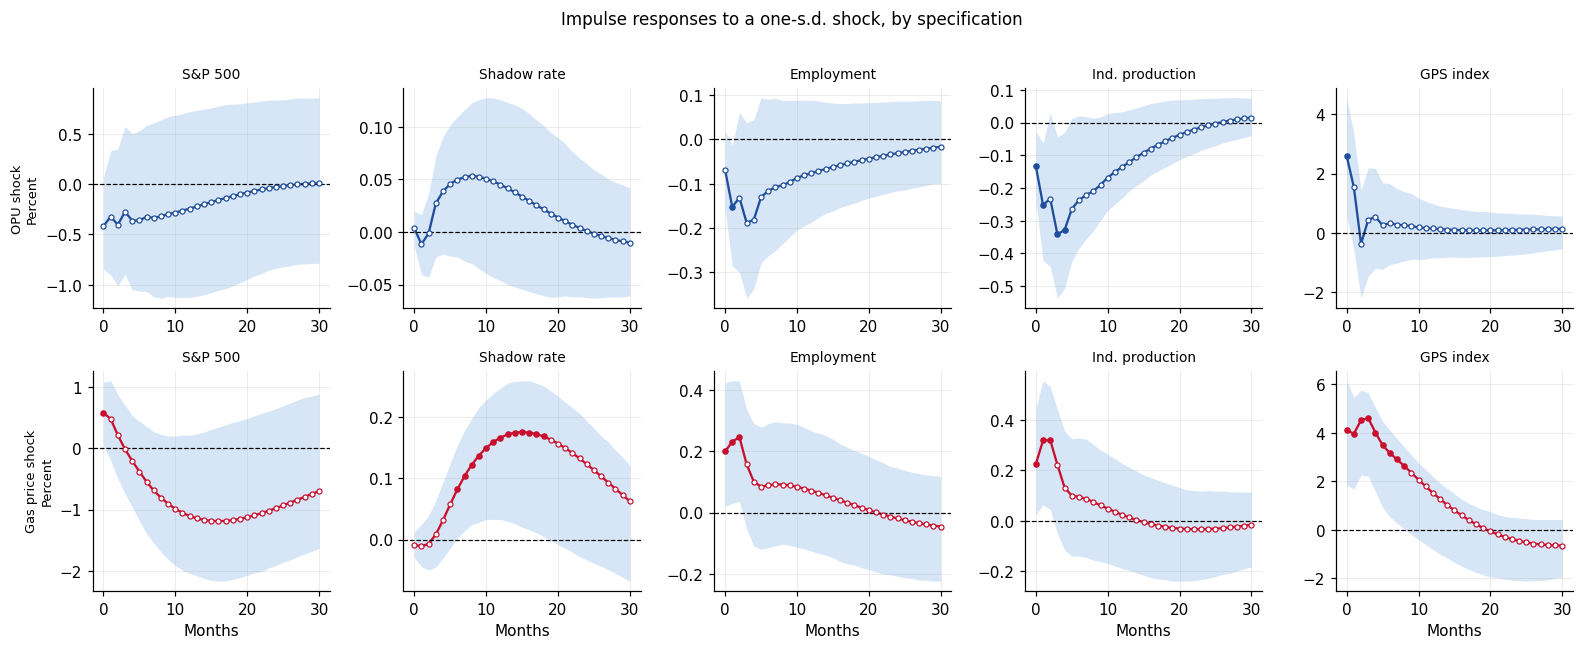

In [17]:
base = {lab: run_spec(sp) for lab, sp in SPECS.items()}
for lab, r in base.items():
    i = r["i_shock"]
    print(f"{lab:16s} T={len(r['data'])}  shock size = "
          f"{np.sqrt(r['model']['Sigma'][i, i]):.2f}%")


def plot_irf_rows(base, fname=None, title=None):
    labs = list(base.keys())
    ncol = len(SPECS[labs[0]]["order"]) - 1
    fig, axes = plt.subplots(len(labs), ncol, figsize=(2.9*ncol, 2.9*len(labs)),
                             squeeze=False)
    h = np.arange(HORIZON + 1)
    for row, lab in enumerate(labs):
        r = base[lab]; d = r["data"]
        cols = [c for c in d.columns if c != SPECS[lab]["shock"]]
        for k, name in enumerate(cols):
            ax = axes[row, k]; j = pos(d, name)
            ax.fill_between(h, r["lo"][:, j], r["hi"][:, j], color=BAND, alpha=.6, lw=0)
            sig = (r["lo"][:, j] > 0) | (r["hi"][:, j] < 0)
            c = SPECS[lab]["color"]
            ax.plot(h, r["point"][:, j], color=c, lw=1.5)
            ax.scatter(h[sig], r["point"][sig, j], s=11, color=c, zorder=4)
            ax.scatter(h[~sig], r["point"][~sig, j], s=11, facecolors="white",
                       edgecolors=c, lw=.8, zorder=4)
            ax.axhline(0, color="k", lw=.8, ls="--")
            ax.set_title(name, fontsize=9)
            if k == 0:
                ax.set_ylabel(f"{lab}\n{UNITS.get(name,'')}", fontsize=8.5)
            if row == len(labs) - 1:
                ax.set_xlabel("Months")
    if title:
        fig.suptitle(title, y=1.01, fontsize=11)
    plt.tight_layout()
    if fname:
        plt.savefig(OUT_DIR / fname, bbox_inches="tight")
    plt.show()


plot_irf_rows(base, "fig3_baseline_irf.png",
              "Impulse responses to a one-s.d. shock, by specification")

In [18]:
rows = []
for lab, r in base.items():
    g = r["point"][:, r["i_resp"]]
    k = int(np.argmax(np.abs(g)))
    imp = r["point"][0, r["i_shock"]]
    sig = (r["lo"][:, r["i_resp"]] > 0) | (r["hi"][:, r["i_resp"]] < 0)
    rows.append({"Spec": lab, "Shock": SPECS[lab]["shock"], "T": len(r["data"]),
                 "Impact on shock var (%)": round(imp, 2),
                 f"Peak {RESP_NAME}": round(g[k], 3), "Peak month": k,
                 "Sig. at peak": bool(sig[k]), "Months significant": int(sig.sum()),
                 "Peak per +10% shock": round(g[k]*10/imp, 2)})
peak_table = pd.DataFrame(rows).set_index("Spec")
display(peak_table)
peak_table.to_csv(OUT_DIR / "table_peak.csv")
print(f"\nWith RESP_LOG={RESP_LOG}, '{RESP_NAME}' responses read as "
      f"{'percent changes' if RESP_LOG else 'index points'}.")

,Shock,T,Impact on shock var (%),Peak GPS index,Peak month,Sig. at peak,Months significant,Peak per +10% shock
Spec,,,,,,,,
OPU shock,OPU,195,49.22,2.592,0,True,1,0.53
Gas price shock,Real gas price,198,5.04,4.596,3,True,9,9.11



With RESP_LOG=True, 'GPS index' responses read as percent changes.


---
## 7. Forecast error variance decomposition


Share of each variable's forecast error variance attributable to the shock.

In [19]:
FEVD_HORIZONS = [1, 6, 12, 24, 36]

tabs = {}
for lab, r in base.items():
    dec = fevd(r["model"]["A"], r["model"]["Sigma"], FEVD_HORIZONS)
    t = pd.DataFrame({H: dec[H][:, r["i_shock"]] for H in FEVD_HORIZONS},
                     index=r["data"].columns).T
    tabs[lab] = t.drop(columns=[SPECS[lab]["shock"]])
    tabs[lab].index.name = "Horizon"
fevd_table = pd.concat(tabs, axis=1)
display(fevd_table.round(2))
fevd_table.round(3).to_csv(OUT_DIR / "table3_fevd.csv")

OPU shock                                                   \
          S&P 500 Shadow rate Employment Ind. production GPS index   
Horizon                                                              
1            0.01        0.00       0.01            0.01      0.06   
6            0.01        0.01       0.03            0.07      0.03   
12           0.01        0.02       0.03            0.09      0.03   
24           0.01        0.01       0.03            0.08      0.02   
36           0.00        0.01       0.03            0.08      0.02   

        Gas price shock                                                   
                S&P 500 Shadow rate Employment Ind. production GPS index  
Horizon                                                                   
1                  0.02        0.00       0.05            0.04      0.15  
6                  0.01        0.01       0.05            0.06      0.33  
12                 0.04        0.10       0.04            0.05      0.35  
24                 0.09        0.21       0.04            0.04      0.29  
36                 0.08        0.22       0.03            0.04      0.27

---
## 8. Direct versus indirect effects




| Experiment | Left switched on in the GPS equation | Reads as |
|---|---|---|
| **Baseline** | everything | total effect |
| **CF: + real activity** | shock, employment, industrial production | direct + household-budget channel |
| **CF: shock only** | the shock alone | pure direct effect |
| **Bivariate VAR** | (2-variable system) | direct effect, alternative check |




In [20]:
def make_cf_transform(keep, eq):
    def f(m, H, shock):
        Ac, Pc = counterfactual_dynamics(m["A"], m["Sigma"], keep=keep, eq=eq)
        return irf_chol(Ac, m["Sigma"], H, shock, P=Pc)
    return f


def decompose(spec, r):
    """Baseline + two counterfactuals + a bivariate VAR, all for the response index."""
    d = spec["data"]; Y = d.values
    i_s, i_r = r["i_shock"], r["i_resp"]
    i_emp, i_ip = pos(d, "Employment"), pos(d, "Ind. production")
    dt = det_terms(d)
    out = {"Baseline": (r["point"][:, i_r], r["lo"][:, i_r], r["hi"][:, i_r])}

    pt, lo, hi, _ = irf_with_bands(Y, NLAGS, HORIZON, i_s, det=dt,
                                   transform=make_cf_transform((i_s, i_emp, i_ip), i_r))
    out["CF: + real activity"] = (pt[:, i_r], lo[:, i_r], hi[:, i_r])

    pt, lo, hi, _ = irf_with_bands(Y, NLAGS, HORIZON, i_s, det=dt,
                                   transform=make_cf_transform((i_s,), i_r))
    out["CF: shock only"] = (pt[:, i_r], lo[:, i_r], hi[:, i_r])

    dbi = d[[spec["shock"], RESP_NAME]]
    pt, lo, hi, _ = irf_with_bands(dbi.values, NLAGS, HORIZON, 0, det=det_terms(dbi))
    out["Bivariate VAR"] = (pt[:, 1], lo[:, 1], hi[:, 1])
    return out


direct = {lab: decompose(SPECS[lab], base[lab]) for lab in SPECS}
print("decompositions done for:", ", ".join(direct))

decompositions done for: OPU shock, Gas price shock


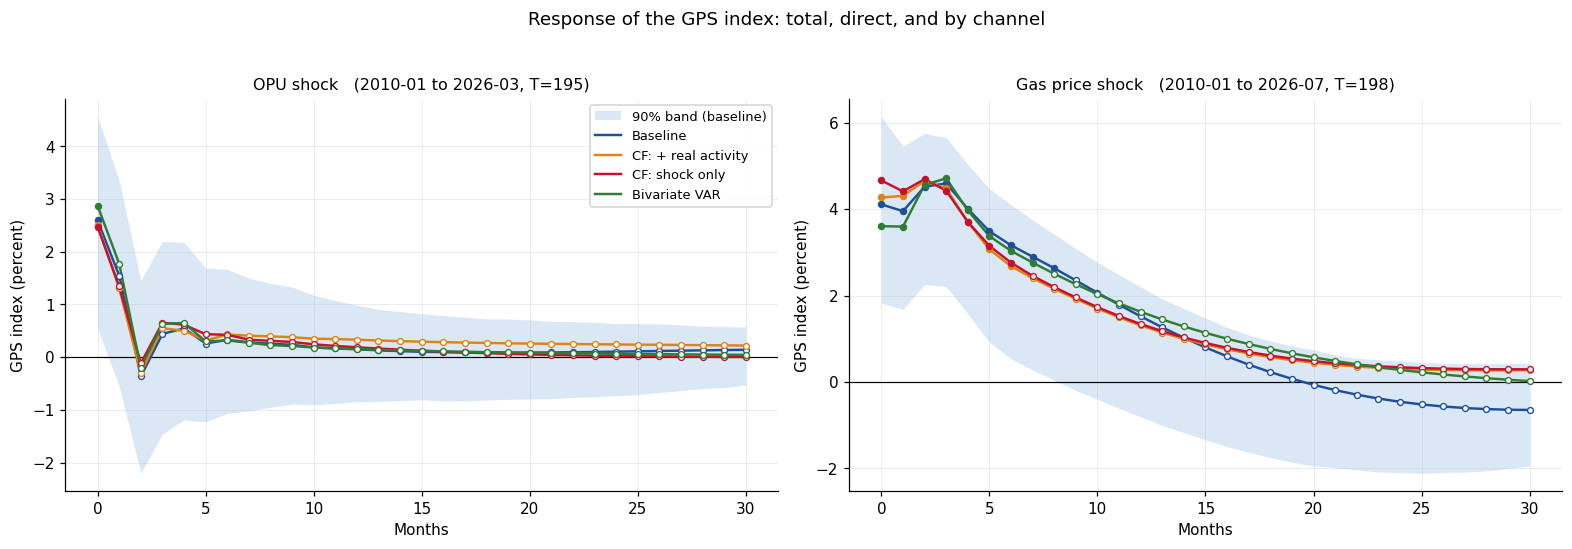

In [22]:
COLORS = {"Baseline": BLUE, "CF: + real activity": ORANGE,
          "CF: shock only": RED, "Bivariate VAR": GREEN}
h = np.arange(HORIZON + 1)

fig, axes = plt.subplots(1, len(direct), figsize=(7.2*len(direct), 4.8), squeeze=False)
for ax, (lab, res) in zip(axes[0], direct.items()):
    b_pt, b_lo, b_hi = res["Baseline"]
    ax.fill_between(h, b_lo, b_hi, color=BAND, alpha=.55, lw=0,
                    label=f"{CI}% band (baseline)")
    ax.axhline(0, color="k", lw=.8)
    for name, (pt, lo, hi) in res.items():
        sig, c = (lo > 0) | (hi < 0), COLORS[name]
        ax.plot(h, pt, color=c, lw=1.6, label=name, zorder=3)
        ax.scatter(h[sig], pt[sig], s=15, color=c, zorder=4)
        ax.scatter(h[~sig], pt[~sig], s=15, facecolors="white", edgecolors=c, lw=.9, zorder=4)
    d = SPECS[lab]["data"]
    ax.set_title(f"{lab}   ({d.index[0]} to {d.index[-1]}, T={len(d)})", fontsize=10.5)
    ax.set_xlabel("Months")
    ax.set_ylabel(f"{RESP_NAME} ({UNITS[RESP_NAME].lower()})")
axes[0][0].legend(fontsize=8.5, loc="best", framealpha=.85, frameon=True)
fig.suptitle(f"Response of the {RESP_NAME}: total, direct, and by channel", y=1.03, fontsize=12)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig4_direct_effects.png", bbox_inches="tight")
plt.show()

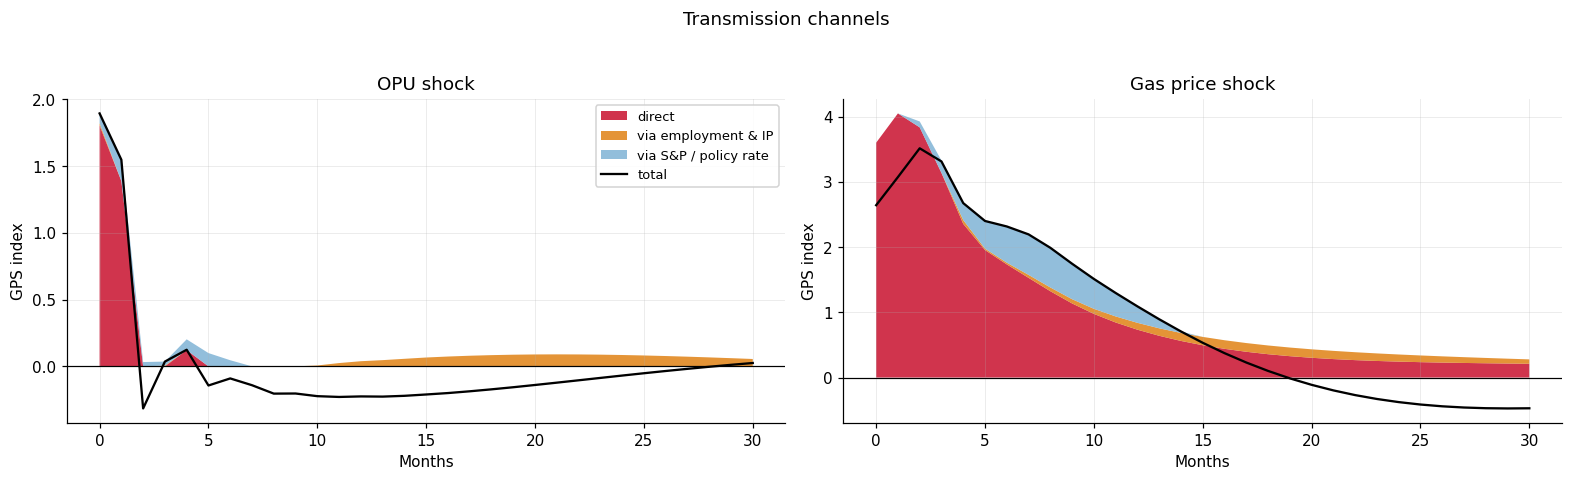

Areas clip negative contributions to zero so the shading reads cleanly. If a channel
is negative the black total line sits below the stack -- trust the table.



Total  Direct  Via employment & IP  \
Spec            Horizon                                       
OPU shock       3        0.036  -0.000                0.006   
                6       -0.090  -0.101               -0.035   
                12      -0.225  -0.120                0.039   
                18      -0.172  -0.065                0.084   
                24      -0.069  -0.029                0.085   
                30       0.025  -0.010                0.055   
Gas price shock 3        3.316   3.139               -0.014   
                6        2.318   1.737                0.026   
                12       1.092   0.734                0.106   
                18       0.102   0.358                0.134   
                24      -0.377   0.244                0.110   
                30      -0.472   0.211                0.068   

                         Via S&P / policy rate  Direct share  
Spec            Horizon                                       
OPU shock       3                        0.030        -0.000  
                6                        0.046         1.121  
                12                      -0.144         0.531  
                18                      -0.191         0.377  
                24                      -0.125         0.423  
                30                      -0.020        -0.393  
Gas price shock 3                        0.191         0.947  
                6                        0.555         0.749  
                12                       0.252         0.672  
                18                      -0.391         3.524  
                24                      -0.731        -0.648  
                30                      -0.750        -0.448

In [ ]:
# ---- channel decomposition ------------------------------------------------------
fig, axes = plt.subplots(1, len(direct), figsize=(7.2*len(direct), 4.2), squeeze=False)
chan_rows = []
for ax, (lab, res) in zip(axes[0], direct.items()):
    total = res["Baseline"][0]
    dir_  = res["CF: shock only"][0]
    viaact = res["CF: + real activity"][0] - dir_
    other  = total - res["CF: + real activity"][0]
    ax.axhline(0, color="k", lw=.8)
    ax.stackplot(h, np.clip(dir_, 0, None), np.clip(viaact, 0, None), np.clip(other, 0, None),
                 labels=["direct", "via employment & IP", "via S&P / policy rate"],
                 colors=[RED, ORANGE, "#7fb3d5"], alpha=.85)
    ax.plot(h, total, color="k", lw=1.5, label="total")
    ax.set_title(lab); ax.set_xlabel("Months"); ax.set_ylabel(RESP_NAME)
    for hh in (3, 6, 12, 18, 24, 30):
        chan_rows.append({"Spec": lab, "Horizon": hh, "Total": total[hh], "Direct": dir_[hh],
                          "Via employment & IP": viaact[hh], "Via S&P / policy rate": other[hh],
                          "Direct share": dir_[hh]/total[hh] if total[hh] else np.nan})
axes[0][0].legend(fontsize=8.5, loc="best", framealpha=.85, frameon=True)
fig.suptitle("Transmission channels", y=1.03)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig4b_channels.png", bbox_inches="tight"); plt.show()

print("Areas clip negative contributions to zero so the shading reads cleanly. If a channel")
print("is negative the black total line sits below the stack -- trust the table.\n")
channel_table = pd.DataFrame(chan_rows).set_index(["Spec", "Horizon"]).round(3)
display(channel_table)
channel_table.to_csv(OUT_DIR / "table_channels.csv")

---
## 9. Robustness
### 9.1 Alternative shock measures

Here each spec gets its natural
family of alternatives: OPU against broad uncertainty measures (VIX, EPU), and the retail gasoline
price against nominal retail and WTI crude.



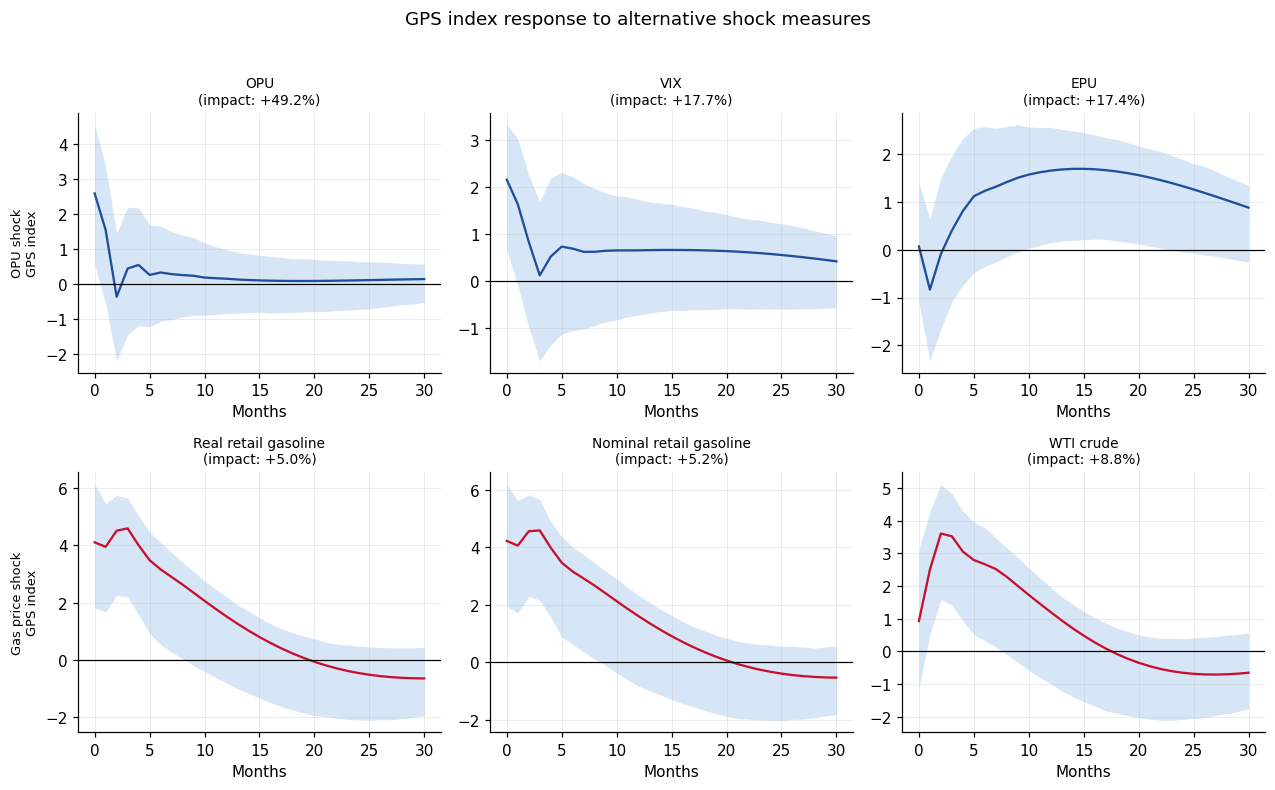


Shock sizes differ across proxies, so compare per-1%-of-shock magnitudes:



Peak  Impact (%)  Peak per +1%
Spec            Measure                                                 
OPU shock       OPU                      2.592      49.223         0.053
                VIX                      2.151      17.689         0.122
                EPU                      1.692      17.397         0.097
Gas price shock Real retail gasoline     4.596       5.043         0.911
                Nominal retail gasoline  4.588       5.208         0.881
                WTI crude                3.612       8.830         0.409

In [23]:
ALTS = {"OPU shock": [("OPU", opu_s)]
                     + [(lab, L100(macro[k])) for k, lab in
                        [("vix", "VIX"), ("epu", "EPU")] if k in macro],
        "Gas price shock": [("Real retail gasoline", gas_s),
                            ("Nominal retail gasoline", L100(macro["gas_nom"]))]
                           + ([("WTI crude", L100(macro["oil_wti"]))]
                              if "oil_wti" in macro else [])}

alt_res = {}
for lab, alist in ALTS.items():
    base_spec = SPECS[lab]
    for nm, series in alist:
        sp = dict(base_spec); sp["series"] = series.rename(base_spec["shock"])
        sp["data"] = build_dataset(sp)
        r = run_spec(sp)
        alt_res[(lab, nm)] = (r["point"][:, r["i_resp"]], r["lo"][:, r["i_resp"]],
                              r["hi"][:, r["i_resp"]], r["point"][0, r["i_shock"]])

ncol = max(len(v) for v in ALTS.values())
fig, axes = plt.subplots(len(ALTS), ncol, figsize=(3.9*ncol, 3.5*len(ALTS)), squeeze=False)
for row, (lab, alist) in enumerate(ALTS.items()):
    for k in range(ncol):
        ax = axes[row, k]
        if k >= len(alist):
            ax.set_visible(False); continue
        nm = alist[k][0]
        pt, lo, hi, imp = alt_res[(lab, nm)]
        ax.fill_between(h, lo, hi, color=BAND, alpha=.6, lw=0)
        ax.plot(h, pt, color=SPECS[lab]["color"], lw=1.5); ax.axhline(0, color="k", lw=.8)
        ax.set_title(f"{nm}\n(impact: {imp:+.1f}%)", fontsize=9)
        ax.set_xlabel("Months")
        if k == 0:
            ax.set_ylabel(f"{lab}\n{RESP_NAME}", fontsize=8.5)
fig.suptitle(f"{RESP_NAME} response to alternative shock measures", y=1.02)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig5_alt_shocks.png", bbox_inches="tight"); plt.show()

print("\nShock sizes differ across proxies, so compare per-1%-of-shock magnitudes:\n")
display(pd.DataFrame([{"Spec": lab, "Measure": nm,
                       "Peak": v[0][int(np.argmax(np.abs(v[0])))],
                       "Impact (%)": v[3],
                       "Peak per +1%": v[0][int(np.argmax(np.abs(v[0])))]/v[3]}
                      for (lab, nm), v in alt_res.items()]
                     ).set_index(["Spec", "Measure"]).round(3))

---
## 10. Correlations


In [24]:
comp = pd.DataFrame({
    "OPU":                         opu_s,
    "Real gas price (log)":        gas_s,
    "Nominal gas price (log)":     L100(macro["gas_nom"]),
    "WTI crude (log)":             L100(macro["oil_wti"]) if "oil_wti" in macro else None,
    "VIX (log)":                   L100(macro["vix"]) if "vix" in macro else None,
    "EPU (log)":                   L100(macro["epu"]) if "epu" in macro else None,
    "Unemployment rate":           macro.get("unrate"),
    "Employment (log)":            L100(macro["emp"]),
    "Industrial production (log)": L100(macro["ip"]),
    "S&P 500 (log)":               L100(macro["sp500"]),
    RESP_NAME:                     resp_s,
}).dropna(axis=1, how="all")

sub = comp.loc[pd.Period(SAMPLE_START, "M"):pd.Period(SAMPLE_END, "M")].dropna()
corr_table = sub.corr()[["OPU", "Real gas price (log)", RESP_NAME]].round(2)
display(corr_table)
corr_table.to_csv(OUT_DIR / "table4_correlations.csv")

print(f"\nSample for correlations: {sub.index[0]} to {sub.index[-1]}, n={len(sub)}\n")
print(f"corr(OPU, {RESP_NAME})            = {sub['OPU'].corr(sub[RESP_NAME]):.2f}")
print(f"corr(real gas price, {RESP_NAME}) = "
      f"{sub['Real gas price (log)'].corr(sub[RESP_NAME]):.2f}")
print(f"corr(OPU, real gas price)         = "
      f"{sub['OPU'].corr(sub['Real gas price (log)']):.2f}")

,OPU,Real gas price (log),GPS index
OPU,1.00,0.01,0.46
Real gas price (log),0.01,1.00,0.32
Nominal gas price (log),0.06,0.84,0.60
WTI crude (log),-0.02,0.88,0.41
VIX (log),0.34,-0.02,0.28
EPU (log),0.15,-0.16,0.21
Unemployment rate,-0.01,0.36,-0.27
Employment (log),0.03,-0.50,0.32
Industrial production (log),-0.04,-0.11,0.26
S&P 500 (log),0.05,-0.52,0.34



Sample for correlations: 2010-01 to 2026-03, n=194

corr(OPU, GPS index)            = 0.46
corr(real gas price, GPS index) = 0.32
corr(OPU, real gas price)         = 0.01
